In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import sys
import re
import os
import glob
from matplotlib import rcParams
import random
from matplotlib.colors import LogNorm

%matplotlib inline


rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

In [26]:
path = "/data/elena/data/Gd/p_270"
filename = os.path.join(path, "WCTE_merged_production_R2408.root")  #already processed data

with uproot.open(filename) as file:
    for key in file.keys():
        print(f"Tree: {key}")

match = re.search(r'R(\d{4})\.root', filename)
if match:
    run_number = match.group(1)
else:
    run_number = "Unknown"

print(f"Detected Run Number: {run_number}")

Tree: WCTEReadoutWindows;2081
Tree: WCTEReadoutWindows;2080
Tree: vme_analysis_scalar_results;1
Tree: vme_analysis_run_info;1
Tree: DataQualityMetrics;1
Tree: Configuration;1
Detected Run Number: 2408


In [27]:
with uproot.open(filename) as f:

    print("Trees:\n")

    for key in f.keys():
        tree = f[key]

        # Skip objects that are not TTrees
        if not isinstance(tree, uproot.behaviors.TTree.TTree):
            continue

        print(f"\n=== {key} ===")

        for branch in tree.keys():
            print(branch)

Trees:


=== WCTEReadoutWindows;2081 ===
window_time
start_counter
run_id
sub_run_id
spill_counter
event_number
readout_number
hit_pmt_calibrated_times
hit_pmt_charges
hit_mpmt_slot_ids
hit_pmt_position_ids
hit_pmt_readout_mask
window_data_quality_mask
trigger_board_hit_card_ids
trigger_board_hit_channel_ids
trigger_board_hit_charges
trigger_board_hit_times
trigger_board_waveform_card_ids
trigger_board_waveform_channel_ids
trigger_board_waveform_times
trigger_board_waveforms
vme_t0_time
vme_t1_time
vme_t4_time
vme_t0_time_second_hit
vme_t1_time_second_hit
vme_t4_time_second_hit
vme_time_t0_0
vme_time_t0_1
vme_time_t0_2
vme_time_t0_3
vme_time_t1_0
vme_time_t1_1
vme_time_t1_2
vme_time_t1_3
vme_time_t4_0
vme_time_t4_1
vme_t5_time
vme_t4_l_time
vme_t4_r_time
vme_t4_l_second_hit
vme_t4_r_second_hit
vme_act0_l_charge
vme_act1_l_charge
vme_act2_l_charge
vme_act3_l_charge
vme_act4_l_charge
vme_act5_l_charge
vme_act0_r_charge
vme_act1_r_charge
vme_act2_r_charge
vme_act3_r_charge
vme_act4_r_char

In [24]:
window_branches = [
    "window_data_quality_mask",
    "vme_evt_quality_bitmask",
    "vme_digi_issues_bitmask",

    "T5_HasValidHit",
    "T5_HasMultipleScintillatorsHit",
    "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow",
    "T5_particle_nr",

    "vme_act_eveto",
    "vme_act_tagger",

    "vme_tof_corr",

    "window_time",
    "start_counter",
    "spill_counter",
    "event_number",
    "readout_number",
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_calibrated_times"
]

scalar_branches = [
    "act_eveto_cut",
    "act_tagger_cut",
    
    "tof_mean_pion",

    "n_pions",
    "momentum_mean_pion"  
]

N = 100000000   #all the events, no poner límiteeee!


with uproot.open(filename) as file:
    tree_windows = file["WCTEReadoutWindows"]
    tree_scalars = file["vme_analysis_scalar_results"]
    

    arrays_windows = tree_windows.arrays(
        window_branches,
        entry_start=0,
        entry_stop=N,
        library="ak"
    )
    

    arrays_scalars = tree_scalars.arrays(
        scalar_branches,
        entry_start=0,
        entry_stop=N,
        library="ak"
    )



print("WCTEReadoutWindows data")

for field in arrays_windows.fields:
    print(f"  - {field}")

print("\n vme_analysis_scalar_results data")
for field in arrays_scalars.fields:
    print(f"  - {field}")


print(f"Loaded readout windows: {len(arrays_windows.window_time)}")

WCTEReadoutWindows data
  - window_data_quality_mask
  - vme_evt_quality_bitmask
  - vme_digi_issues_bitmask
  - T5_HasValidHit
  - T5_HasMultipleScintillatorsHit
  - T5_HasOutOfTimeWindow
  - T5_HasInTimeWindow
  - T5_particle_nr
  - vme_act_eveto
  - vme_act_tagger
  - vme_tof_corr
  - window_time
  - start_counter
  - spill_counter
  - event_number
  - readout_number
  - hit_mpmt_slot_ids
  - hit_pmt_position_ids
  - hit_pmt_charges
  - hit_pmt_calibrated_times

 vme_analysis_scalar_results data
  - act_eveto_cut
  - act_tagger_cut
  - tof_mean_pion
  - n_pions
  - momentum_mean_pion
Loaded readout windows: 873864


In [7]:
#GOOD EVENTS

data_quality = arrays_windows["window_data_quality_mask"] == 0
evt_quality  = arrays_windows["vme_evt_quality_bitmask"] == 0
digi_issues  = arrays_windows["vme_digi_issues_bitmask"] == 0

#T5
valid_hit    = arrays_windows["T5_HasValidHit"] == True
mult_scint   = arrays_windows["T5_HasMultipleScintillatorsHit"] == False
out_of_time  = arrays_windows["T5_HasOutOfTimeWindow"] == False
in_time      = arrays_windows["T5_HasInTimeWindow"] == True
particle_nr  = arrays_windows["T5_particle_nr"] == 1


good_mask = (
    data_quality & 
    evt_quality & 
    digi_issues & 
    valid_hit & 
    mult_scint & 
    out_of_time & 
    in_time & 
    particle_nr
)

filtered_windows = arrays_windows[good_mask]


total_events = len(arrays_windows)
n_filtered_events = len(filtered_windows)
fraction = (n_filtered_events / total_events) * 100

print(f"Run number: {run_number}")
print(f"Total number of readout windows loaded: {total_events}")
print(f"Filtered readout windows (Quality Checks): {n_filtered_events}")
print(f"Fraction: {fraction:.3f}%")

Run number: 2408
Total number of readout windows loaded: 873864
Filtered readout windows (Quality Checks): 2562
Fraction: 0.293%


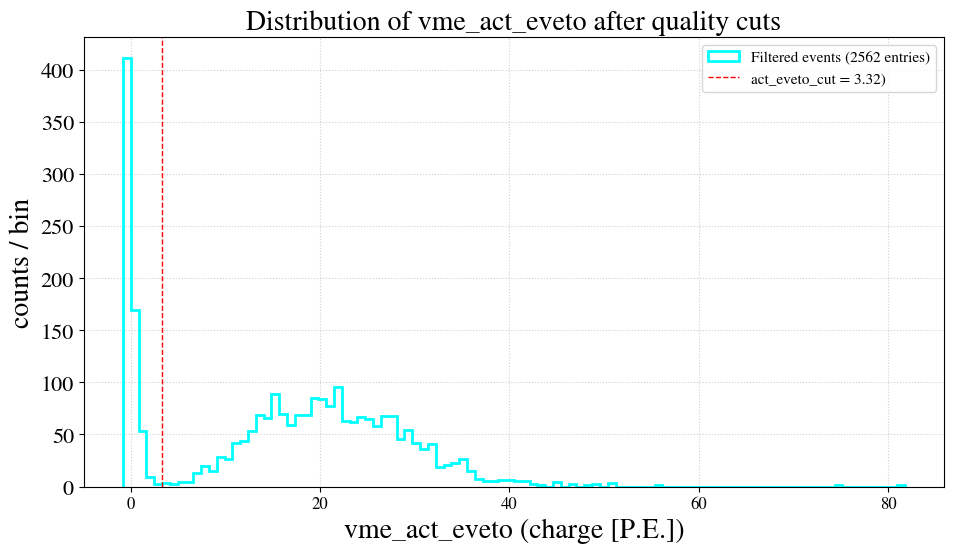

In [8]:
eveto_cut_value = arrays_scalars["act_eveto_cut"][0]
#eveto_data = arrays_windows["vme_act_eveto"]
eveto_data = filtered_windows["vme_act_eveto"]

plt.figure(figsize=(10, 6))

plt.hist(eveto_data, bins=100, histtype="step", linewidth=2, color="cyan", label=f"Filtered events ({len(eveto_data)} entries)")
plt.axvline(x=eveto_cut_value, color="red", linestyle="--", linewidth=1, label=f"act_eveto_cut = {eveto_cut_value:.2f})")

plt.title("Distribution of vme_act_eveto after quality cuts")
plt.xlabel("vme_act_eveto (charge [P.E.])")
plt.ylabel("counts / bin")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

Number of pions: 81


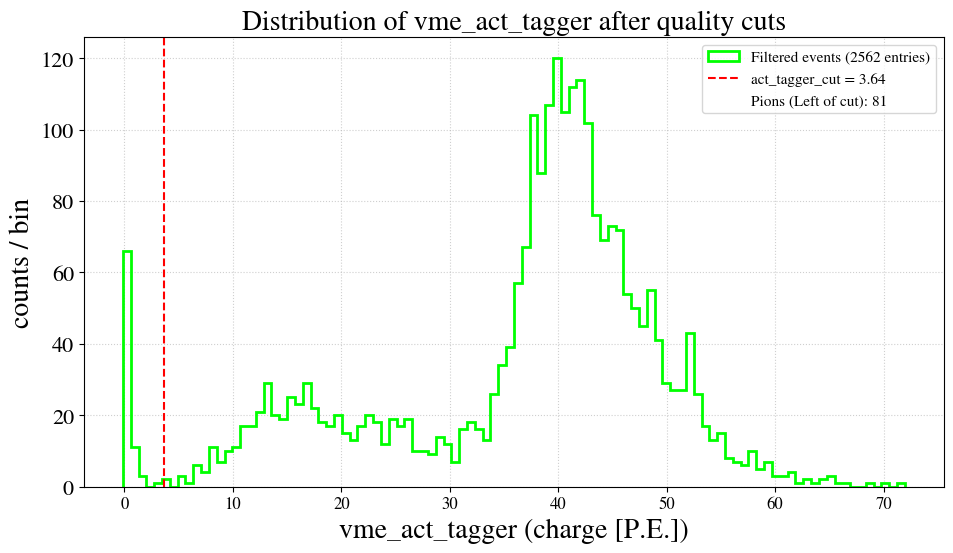

In [9]:
eveto_cut_value = arrays_scalars["act_tagger_cut"][0]
eveto_data = filtered_windows["vme_act_tagger"]

pion_mask = eveto_data < eveto_cut_value
n_pions = np.sum(pion_mask)  

print("Number of pions:", n_pions)

plt.figure(figsize=(10, 6))


plt.hist(eveto_data, bins=100, histtype="step", linewidth=2, color="lime", label=f"Filtered events ({len(eveto_data)} entries)")

plt.axvline(x=eveto_cut_value, color="red", linestyle="--", linewidth=1.5, label=f"act_tagger_cut = {eveto_cut_value:.2f}")


plt.title("Distribution of vme_act_tagger after quality cuts")
plt.xlabel("vme_act_tagger (charge [P.E.])")
plt.ylabel("counts / bin")
plt.grid(True, linestyle=":", alpha=0.6)


plt.plot([], [], ' ', label=f"Pions (Left of cut): {n_pions}")

plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

In [10]:
total_n_pions = arrays_scalars["n_pions"]
print(total_n_pions)  #estos son sin pasar los Quality Checks

[496]


In [11]:
pion_events = filtered_windows[pion_mask]

target_branches = [
    "window_time",
    "start_counter",
    "spill_counter",
    "event_number",
    "readout_number",
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_calibrated_times",
]

df_pions_raw = ak.to_dataframe(pion_events[target_branches])
df_pions_hits = df_pions_raw.reset_index(drop=True)


print(f"Number of pions: {len(pion_events)}")
print(f"Total PMT hits from pion events: {len(df_pions_hits)}")
print(f"Unique spills with pions: {df_pions_hits['spill_counter'].nunique()}")


df_pions_hits.sample(10)

Number of pions: 81
Total PMT hits from pion events: 181440
Unique spills with pions: 72


,window_time,start_counter,spill_counter,event_number,readout_number,hit_mpmt_slot_ids,hit_pmt_position_ids,hit_pmt_charges,hit_pmt_calibrated_times
126643,4.796593e+12,599574123684,330,604476,629912,3,14,229.0,16358.017352
69452,2.291498e+12,286437272831,155,284229,301311,95,2,145.0,206675.902724
171444,6.325201e+12,790650119901,422,777891,803317,19,11,277.0,166531.852111
166994,6.282325e+12,785290616205,419,772319,797712,82,5,105.0,163218.064747
85056,2.939446e+12,367430753056,200,364554,386065,22,11,411.0,74295.312016
166359,6.282325e+12,785290616205,419,772319,797712,56,18,70.0,93594.152063
180938,7.001919e+12,875239927879,470,864470,889926,49,8,220.0,83254.604726
110966,4.062416e+12,507801981192,279,512000,533541,40,3,1460.0,64059.475594
39038,1.412919e+12,176614836208,94,168736,185234,10,0,227.0,64711.630353
99491,3.731355e+12,466419358444,256,468554,490290,49,14,227.0,164517.242527


/tmp/ipykernel_1413931/3381639028.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pions_per_spill = df_pions_raw.groupby("spill_counter").apply(


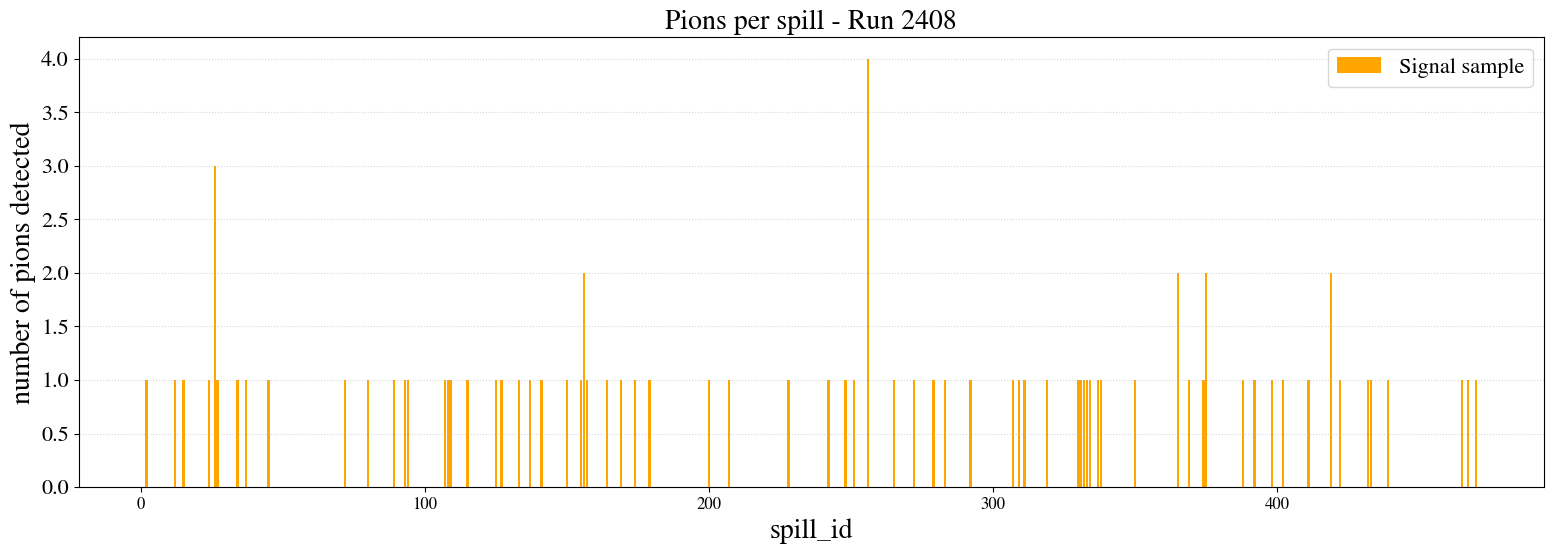

In [12]:
#Group by spill_counter and count the unique event entries from the MultiIndex level 0
pions_per_spill = df_pions_raw.groupby("spill_counter").apply(
    lambda x: x.index.get_level_values(0).nunique()
)
df_pion_counts = pions_per_spill.to_frame(name="number_of_pions").reset_index()

plt.figure()
plt.bar(df_pion_counts["spill_counter"],df_pion_counts["number_of_pions"],color="orange",label="Signal sample",)

plt.title(f"Pions per spill - Run {run_number}")
plt.xlabel("spill_id")
plt.ylabel("number of pions detected")
plt.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
tagger_cut_value = arrays_scalars["act_tagger_cut"][0]
tagger_data = filtered_windows["vme_act_tagger"]
pion_mask = tagger_data < tagger_cut_value

all_filtered_spills = np.unique(filtered_windows.spill_counter)
spills_with_pions = np.unique(filtered_windows.spill_counter[pion_mask])
spills_without_pions = np.setdiff1d(all_filtered_spills, spills_with_pions)

mask_signal_spills = np.isin(filtered_windows.spill_counter, spills_with_pions)
mask_bkg_spills = np.isin(filtered_windows.spill_counter, spills_without_pions)

signal_sample = filtered_windows[mask_signal_spills]
bkg_sample = filtered_windows[mask_bkg_spills]


print(f"Evaluated spills (passing data quality checks):  {len(all_filtered_spills)}")
print(f"  - Spills with pions (signal):                  {len(spills_with_pions)}")
print(f"  - Spills without pions (background):           {len(spills_without_pions)}")
print("---------------------------------------------------------------------------------------")
print(f"Total readout_windows in signal_sample:                   {len(signal_sample)}")
print(f"Total readout_windows in bkg_sample:                      {len(bkg_sample)}")

Evaluated spills (passing data quality checks):  431
  - Spills with pions (signal):                  72
  - Spills without pions (background):           359
---------------------------------------------------------------------------------------
Total readout_windows in signal_sample:                   532
Total readout_windows in bkg_sample:                      2030


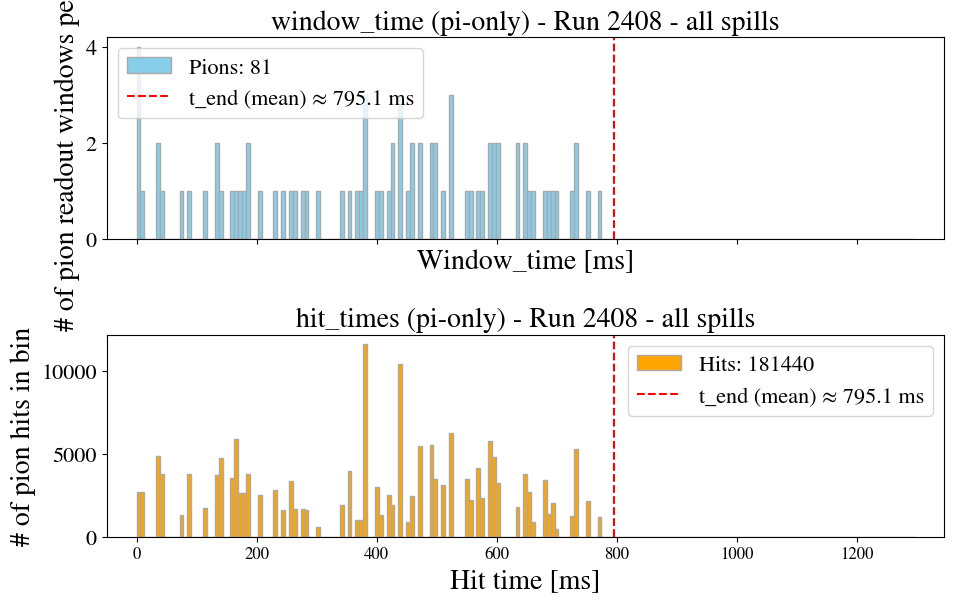

In [14]:
unique_spills_with_pions = np.unique(filtered_windows.spill_counter[pion_mask])

if len(unique_spills_with_pions) == 0:
    raise ValueError("No pions found in any spill with the current cut parameters.")

all_pion_window_times_ms = []
all_pion_hit_times_ms = []
all_t_spill_ends = []
all_t_max_spills = []


#data accumulation by aligning all spills
for spill_id in unique_spills_with_pions:
    #Beam time base calibration using raw window data 
    spill_raw_mask = arrays_windows.spill_counter == spill_id
    arrays_spill_raw = arrays_windows[spill_raw_mask]

    window_times_us_raw = ak.to_numpy(arrays_spill_raw.window_time) / 1000
    if len(window_times_us_raw) == 0:
        continue

    t_start_spill_us = np.min(window_times_us_raw)
    t_max_spill_ms = (np.max(window_times_us_raw) - t_start_spill_us) / 1000
    all_t_max_spills.append(t_max_spill_ms)
    all_t_spill_ends.append(t_max_spill_ms - 500)

    #extract filtered pions belonging to this spill
    pion_spill_mask = (filtered_windows.spill_counter == spill_id) & pion_mask
    pion_spill_events = filtered_windows[pion_spill_mask]
    if len(pion_spill_events) == 0:
        continue

    #align pion window times relative to the spill start
    pion_window_times_us = ak.to_numpy(pion_spill_events.window_time) / 1000
    pion_window_times_rel_ms = (pion_window_times_us - t_start_spill_us) / 1000
    all_pion_window_times_ms.extend(pion_window_times_rel_ms)

    #align individual PMT hit times relative to the spill start
    pion_hit_times_absolute = (
        pion_spill_events.window_time[:, None]
        + pion_spill_events.hit_pmt_calibrated_times
    )
    pion_hit_times_us = ak.to_numpy(ak.flatten(pion_hit_times_absolute)) / 1000
    pion_hit_times_rel_ms = (pion_hit_times_us - t_start_spill_us) / 1000
    all_pion_hit_times_ms.extend(pion_hit_times_rel_ms)

# Convert accumulated lists to standard np arrays
all_pion_window_times_ms = np.array(all_pion_window_times_ms)
all_pion_hit_times_ms = np.array(all_pion_hit_times_ms)

#mean beam profile statistics
mean_t_max_spill = np.mean(all_t_max_spills)
mean_t_spill_end = np.mean(all_t_spill_ends)

bins = np.linspace(0, mean_t_max_spill, 200)

fig, axs = plt.subplots(2, 1, sharex=True, figsize = (10, 6.5))

total_pions = len(all_pion_window_times_ms)
total_hits = len(all_pion_hit_times_ms)

axs[0].hist(all_pion_window_times_ms, bins=bins, color="skyblue", edgecolor="darkgray", label=f"Pions: {total_pions}")
axs[0].axvline(mean_t_spill_end, color="red", linestyle="--", label=f"t_end (mean) ≈ {mean_t_spill_end:.1f} ms")

axs[0].set_ylabel("# of pion readout windows per bin")
axs[0].set_xlabel("Window_time [ms]")
axs[0].set_title(f"window_time (pi-only) - Run {run_number} - all spills")
axs[0].set_xlim(-50, mean_t_max_spill + 50)
axs[0].legend(loc="upper left")


axs[1].hist(all_pion_hit_times_ms, bins=bins, color="orange", edgecolor="darkgray", label=f"Hits: {total_hits}")
axs[1].axvline(mean_t_spill_end, color="red", linestyle="--", label=f"t_end (mean) ≈ {mean_t_spill_end:.1f} ms")

axs[1].set_xlabel("Hit time [ms]")
axs[1].set_ylabel("# of pion hits in bin")
axs[1].set_title(f"hit_times (pi-only) - Run {run_number} - all spills")
axs[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [15]:
pion_events = filtered_windows[pion_mask]

target_branches = [
    "window_time",
    "start_counter",
    "spill_counter",
    "event_number",
    "readout_number",
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_calibrated_times",
]

df_pions_raw = ak.to_dataframe(pion_events[target_branches])
df_pions_hits = df_pions_raw.reset_index(drop=True)


print(f"Number of pions: {len(pion_events)}")
print(f"Total PMT hits from pion events: {len(df_pions_hits)}")
print(f"Unique spills with pions: {df_pions_hits['spill_counter'].nunique()}")


df_pions_hits.sample(10)

Number of pions: 81
Total PMT hits from pion events: 181440
Unique spills with pions: 72


,window_time,start_counter,spill_counter,event_number,readout_number,hit_mpmt_slot_ids,hit_pmt_position_ids,hit_pmt_charges,hit_pmt_calibrated_times
16989,3.860899e+11,48261236281,26,49177,49148,70,8,152.0,119789.792810
14753,3.857094e+11,48213677214,26,49131,49141,92,15,191.0,3532.621460
3625,3.280386e+10,4100482750,2,3772,3792,51,6,681.0,163228.644592
115458,4.465659e+12,558207352059,307,564896,586501,81,10,389.0,105407.479973
5673,1.845417e+11,23067709893,12,22710,22726,55,3,151.0,119778.705325
102858,3.731562e+12,466445274682,256,468576,490406,50,12,130.0,114034.626063
131709,4.811410e+12,601426213031,331,606408,631726,105,17,159.0,111787.866201
127622,4.796593e+12,599574123684,330,604476,629912,5,14,235.0,16366.691426
93678,3.616365e+12,452045681857,248,453448,475084,19,12,415.0,145615.392555
25828,5.348569e+11,66857117501,37,69980,70111,70,5,144.0,207638.008870


In [16]:
TAU_12B = 30.0  #12B
TAU_9LI = 257.0  #Li9
TAU_16N = 7130.0  #16N

spill_timing_map = {}
unique_spills = np.unique(arrays_windows.spill_counter)

for spill_id in unique_spills:
    spill_raw_mask = arrays_windows.spill_counter == spill_id
    window_times_us = ak.to_numpy(arrays_windows[spill_raw_mask].window_time) / 1000

    if len(window_times_us) > 0:
        t_start_spill_us = np.min(window_times_us)
        t_max_spill_ms = (np.max(window_times_us) - t_start_spill_us) / 1000
        t_end_spill_ms = t_max_spill_ms - 500.0
        spill_timing_map[spill_id] = (t_start_spill_us, t_end_spill_ms)

# Aggregate hit-level data into standard single-row-per-pion events
df_pion_events = (
    df_pions_raw.groupby(
        [
            "window_time",
            "start_counter",
            "spill_counter",
            "event_number",
            "readout_number",
        ]
    )
    .agg(n_hits_produced=("hit_pmt_charges", "count"))
    .reset_index()
)

# Map the exact spill timing and compute physical variables
df_pion_events["t_start_spill_us"] = df_pion_events["spill_counter"].map(
    lambda s: spill_timing_map[s][0] if s in spill_timing_map else 0.0
)
df_pion_events["t_end_spill [ms]"] = df_pion_events["spill_counter"].map(
    lambda s: spill_timing_map[s][1] if s in spill_timing_map else 0.0
)

# Calculate relative pion time t_pi
df_pion_events["t_pi [ms]"] = ((df_pion_events["window_time"] / 1000.0)- df_pion_events["t_start_spill_us"]) / 1000.0

# Drop the temporary start time column
df_pion_events = df_pion_events.drop(columns=["t_start_spill_us"])

#time difference Delta_t
dt = df_pion_events["t_end_spill [ms]"] - df_pion_events["t_pi [ms]"]

df_pion_events["Prob_12B (30ms)"] = np.where(dt >= 0, np.exp(-dt / TAU_12B), 0.0)
df_pion_events["Prob_9Li (257ms)"] = np.where(dt >= 0, np.exp(-dt / TAU_9LI), 0.0)
df_pion_events["Prob_16N (7130ms)"] = np.where(dt >= 0, np.exp(-dt / TAU_16N), 0.0)

print(f"Total pions: {len(df_pion_events)}")
df_pion_events.head(10)

Total pions: 81


,window_time,start_counter,spill_counter,event_number,readout_number,n_hits_produced,t_end_spill [ms],t_pi [ms],Prob_12B (30ms),Prob_9Li (257ms),Prob_16N (7130ms)
0,3.280386e+10,4100482750,2,3772,3792,3768,799.945176,40.101472,1.000313e-11,0.051996,0.898912
1,1.845417e+11,23067709893,12,22710,22726,2354,788.045816,576.474672,8.653544e-04,0.439010,0.970763
2,2.179502e+11,27243778140,15,28355,28222,3104,782.786776,382.085112,1.582156e-06,0.210315,0.945351
3,3.573181e+11,44664768185,24,45394,45382,4151,792.934128,569.778840,5.881611e-04,0.419661,0.969187
4,3.857094e+11,48213677214,26,49131,49141,2613,805.806888,175.915368,7.610029e-10,0.086213,0.915446
5,3.860899e+11,48261236281,26,49177,49148,2204,805.806888,556.387904,2.450701e-04,0.378893,0.965623
6,3.862629e+11,48282856272,26,49190,49180,3946,805.806888,729.347832,7.818830e-02,0.742668,0.989334
7,3.909560e+11,48869494525,27,51081,51191,2177,781.838632,598.817528,2.241290e-03,0.490591,0.974657
8,5.010979e+11,62637234617,34,64295,64367,1003,805.849016,372.383448,5.308150e-07,0.185141,0.941016
9,5.348569e+11,66857117501,37,69980,70111,2300,793.224960,521.145880,1.151468e-04,0.346916,0.962559


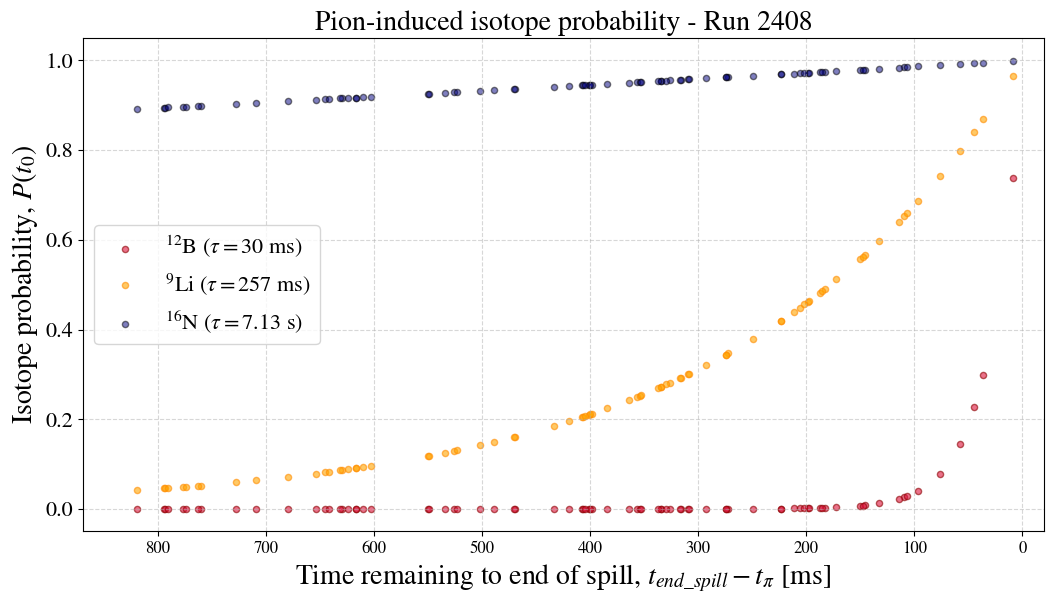

In [17]:
#calculate the time remaining until the end of the spill (dt = t_end_spill - t_pi)
dt_elements = df_pion_events["t_end_spill [ms]"] - df_pion_events["t_pi [ms]"]

fig, ax = plt.subplots(figsize=(11, 6.5)) 

#fixed marker size for all data points
fixed_size = 20

#scatter plot for 12B prob
ax.scatter(
    dt_elements,
    df_pion_events["Prob_12B (30ms)"],
    s=fixed_size,
    color="crimson",
    alpha=0.6,
    edgecolors="darkred",
    label=r"$^{12}$B ($\tau = 30$ ms)",
)

#scatter plot for  Li9 prob
ax.scatter(
    dt_elements,
    df_pion_events["Prob_9Li (257ms)"],
    s=fixed_size,
    color="orange",
    alpha=0.6,
    edgecolors="darkorange",
    label=r"$^{9}$Li ($\tau = 257$ ms)",
)

#scatter plot for 16N prob
ax.scatter(
    dt_elements,
    df_pion_events["Prob_16N (7130ms)"],
    s=fixed_size,
    color="navy",
    alpha=0.5,
    edgecolors="black",
    label=r"$^{16}$N ($\tau = 7.13$ s)",
)

ax.set_xlabel(r"Time remaining to end of spill, $t_{end\_spill} - t_{\pi}$ [ms]")
ax.set_ylabel(r"Isotope probability, $P(t_0)$")
ax.set_title(f"Pion-induced isotope probability - Run {run_number}")

# Invert X-axis to showcase decay profile chronologically towards the end of the spill
ax.set_xlim(dt_elements.max() + 50, -20)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="center left")

plt.tight_layout()
plt.show()

buscar el background continuo del 16N con FV cut (high z)

In [18]:
beam_momentum = -340 
t_start_win = 20.0  #we search 20ms after the t0
t_end_win = 500.0 

TAU_12B = 30.0
TAU_9LI = 257.0
TAU_16N = 7130.0

df_spill_analysis = df_pion_events.copy()

#time remaining within the spill for each individual pion
dt = df_spill_analysis["t_end_spill [ms]"] - df_spill_analysis["t_pi [ms]"]

df_spill_analysis["p_12B"] = np.exp(-dt / TAU_12B) * (np.exp(-t_start_win / TAU_12B) - np.exp(-t_end_win / TAU_12B))
df_spill_analysis["p_9Li"] = np.exp(-dt / TAU_9LI) * (np.exp(-t_start_win / TAU_9LI) - np.exp(-t_end_win / TAU_9LI))
df_spill_analysis["p_16N"] = np.exp(-dt / TAU_16N) * (np.exp(-t_start_win / TAU_16N) - np.exp(-t_end_win / TAU_16N))


spill_groups = df_spill_analysis.groupby("spill_counter")

#structured summary DataFrame
df_by_spill = pd.DataFrame(
    {
        "N pions (total)": spill_groups["event_number"].count(),
        f"N 12B exp ({t_start_win:.0f}-{t_end_win:.0f} ms)": spill_groups[
            "p_12B"
        ]
        .sum()
        .round(2),
        f"N Li9 exp ({t_start_win:.0f}-{t_end_win:.0f} ms)": spill_groups[
            "p_9Li"
        ]
        .sum()
        .round(2),
        f"N 16N exp ({t_start_win:.0f}-{t_end_win:.0f} ms)": spill_groups[
            "p_16N"
        ]
        .sum()
        .round(2),
    }
).reset_index()

df_by_spill.insert(0, "Run", run_number)
df_by_spill.insert(1, "Beam p (MeV/c)", beam_momentum)

df_by_spill = df_by_spill.rename(columns={"spill_counter": "Spill ID"})

df_by_spill.sample(20)

,Run,Beam p (MeV/c),Spill ID,N pions (total),N 12B exp (20-500 ms),N Li9 exp (20-500 ms),N 16N exp (20-500 ms)
39,2408,-340,272,1,0.00,0.07,0.06
8,2408,-340,45,1,0.38,0.76,0.06
32,2408,-340,207,1,0.00,0.04,0.06
30,2408,-340,179,1,0.00,0.10,0.06
37,2408,-340,256,4,0.00,0.89,0.25
5,2408,-340,27,1,0.00,0.38,0.06
21,2408,-340,137,1,0.00,0.20,0.06
65,2408,-340,422,1,0.00,0.05,0.06
35,2408,-340,248,1,0.00,0.44,0.06
45,2408,-340,311,1,0.00,0.04,0.06


In [19]:
t_threshold = 50.0 #Optimized by Helea


#Early window (20 - 50 ms) -> likely B12 
df_spill_analysis["p_12B_early"] = np.exp(-dt / TAU_12B) * (np.exp(-t_start_win / TAU_12B) - np.exp(-t_threshold / TAU_12B))
df_spill_analysis["p_9Li_early"] = np.exp(-dt / TAU_9LI) * (np.exp(-t_start_win / TAU_9LI) - np.exp(-t_threshold / TAU_9LI))
df_spill_analysis["p_16N_early"] = np.exp(-dt / TAU_16N) * (np.exp(-t_start_win / TAU_16N) - np.exp(-t_threshold / TAU_16N))

# late window (50 - 500 ms) -> Li9 ??
df_spill_analysis["p_12B_late"] = np.exp(-dt / TAU_12B) * (np.exp(-t_threshold / TAU_12B) - np.exp(-t_end_win / TAU_12B))
df_spill_analysis["p_9Li_late"] = np.exp(-dt / TAU_9LI) * (np.exp(-t_threshold / TAU_9LI) - np.exp(-t_end_win / TAU_9LI))
df_spill_analysis["p_16N_late"] = np.exp(-dt / TAU_16N) * (np.exp(-t_threshold / TAU_16N) - np.exp(-t_end_win / TAU_16N))

# 2. Grouping and Aggregation by Spill
spill_groups = df_spill_analysis.groupby("spill_counter")

df_by_spill_split = pd.DataFrame(
    {
        "N pions (total)": spill_groups["event_number"].count(),
        #(20-50 ms)
        f"N 12B exp ({t_start_win:.0f}-{t_threshold:.0f} ms)": spill_groups[
            "p_12B_early"
        ]
        .sum()
        .round(2),
        f"N Li9 exp ({t_start_win:.0f}-{t_threshold:.0f} ms)": spill_groups[
            "p_9Li_early"
        ]
        .sum()
        .round(2),
        f"N 16N exp ({t_start_win:.0f}-{t_threshold:.0f} ms)": spill_groups[
            "p_16N_early"
        ]
        .sum()
        .round(2),
        # Late (50-500 ms)
        f"N 12B exp ({t_threshold:.0f}-{t_end_win:.0f} ms)": spill_groups[
            "p_12B_late"
        ]
        .sum()
        .round(2),
        f"N Li9 exp ({t_threshold:.0f}-{t_end_win:.0f} ms)": spill_groups[
            "p_9Li_late"
        ]
        .sum()
        .round(2),
        f"N 16N exp ({t_threshold:.0f}-{t_end_win:.0f} ms)": spill_groups[
            "p_16N_late"
        ]
        .sum()
        .round(2),
    }
).reset_index()

# 3. Inject Experimental Metadata Columns
df_by_spill_split.insert(0, "Run", run_number)
df_by_spill_split.insert(1, "Beam p (MeV/c)", beam_momentum)

# Clean up label indices
df_by_spill_split = df_by_spill_split.rename(
    columns={"spill_counter": "Spill ID"}
)

print(
    f"Early ({t_start_win:.0f}-{t_threshold:.0f}) ms and late ({t_threshold:.0f}-{t_end_win:.0f}) ms"
)
df_by_spill_split.sample(20)

Early (20-50) ms and late (50-500) ms


,Run,Beam p (MeV/c),Spill ID,N pions (total),N 12B exp (20-50 ms),N Li9 exp (20-50 ms),N 16N exp (20-50 ms),N 12B exp (50-500 ms),N Li9 exp (50-500 ms),N 16N exp (50-500 ms)
17,2408,-340,115,1,0.00,0.05,0.00,0.00,0.33,0.06
9,2408,-340,72,1,0.00,0.03,0.00,0.00,0.19,0.06
0,2408,-340,2,1,0.00,0.01,0.00,0.00,0.04,0.05
40,2408,-340,279,1,0.00,0.02,0.00,0.00,0.11,0.06
64,2408,-340,419,2,0.05,0.10,0.01,0.03,0.68,0.12
43,2408,-340,307,1,0.00,0.02,0.00,0.00,0.14,0.06
38,2408,-340,265,1,0.01,0.07,0.00,0.00,0.44,0.06
1,2408,-340,12,1,0.00,0.04,0.00,0.00,0.30,0.06
37,2408,-340,256,4,0.00,0.12,0.02,0.00,0.77,0.23
35,2408,-340,248,1,0.00,0.06,0.00,0.00,0.38,0.06


### new PID

--- Cargando datos para el Run 1936 (p_260) ---


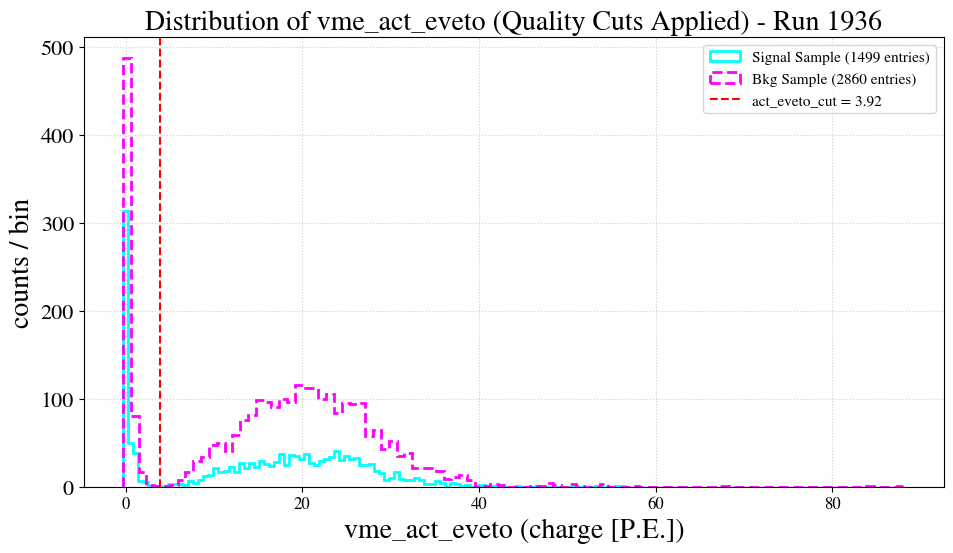

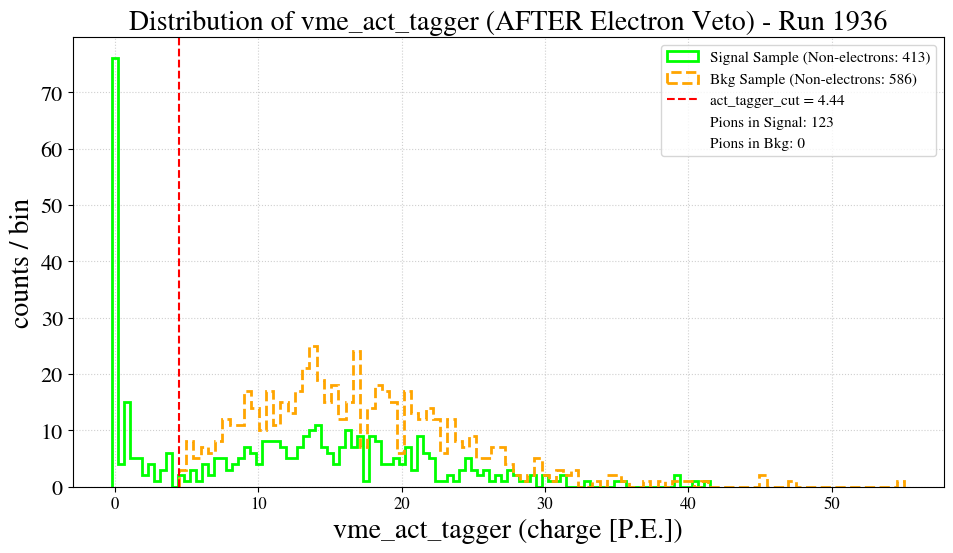

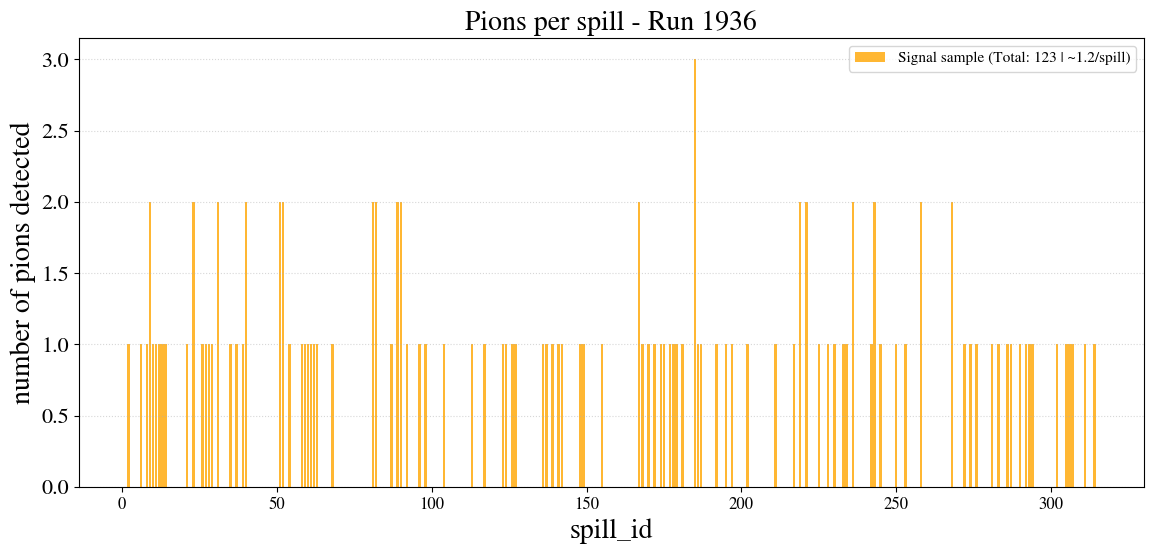

In [21]:
import os
import numpy as np
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------------------------------
# 1. Configuración de entrada
# -----------------------------------------------------------------------------
RUN_NUMBER = 1936
BASE_DIR = "/scratch/elena/9Li/filtered_root"

momentum_dir = "p_340" if RUN_NUMBER in [1846, 1848] else "p_260"
file_signal = os.path.join(BASE_DIR, momentum_dir, f"WCTE_merged_production_R{RUN_NUMBER}_signal.root")
file_bkg    = os.path.join(BASE_DIR, momentum_dir, f"WCTE_merged_production_R{RUN_NUMBER}_bkg.root")

print(f"--- Cargando datos para el Run {RUN_NUMBER} ({momentum_dir}) ---")

branches_needed = [
    "spill_counter", "vme_act_eveto", "vme_act_tagger",
    "window_data_quality_mask", "vme_evt_quality_bitmask", "vme_digi_issues_bitmask",
    "T5_HasValidHit", "T5_HasMultipleScintillatorsHit", "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow", "T5_particle_nr"
]

with uproot.open(file_signal) as f_sig:
    arrays_sig = f_sig["WCTEReadoutWindows"].arrays(branches_needed, library="np")
    scalars_sig = f_sig["vme_analysis_scalar_results"].arrays(library="np")

with uproot.open(file_bkg) as f_bkg:
    arrays_bkg = f_bkg["WCTEReadoutWindows"].arrays(branches_needed, library="np")

eveto_cut_val  = scalars_sig["act_eveto_cut"][0]  if "act_eveto_cut" in scalars_sig else 3.92
tagger_cut_val = scalars_sig["act_tagger_cut"][0] if "act_tagger_cut" in scalars_sig else 2.83

# -----------------------------------------------------------------------------
# Funciones auxiliares de cortes de calidad y veto de electrones
# -----------------------------------------------------------------------------
def get_quality_mask(arr):
    return (
        (arr["window_data_quality_mask"] == 0) &
        (arr["vme_evt_quality_bitmask"] == 0) &
        (arr["vme_digi_issues_bitmask"] == 0) &
        (arr["T5_HasValidHit"] == True) &
        (arr["T5_HasMultipleScintillatorsHit"] == False) &
        (arr["T5_HasOutOfTimeWindow"] == False) &
        (arr["T5_HasInTimeWindow"] == True) &
        (arr["T5_particle_nr"] == 1)
    )

mask_qual_sig = get_quality_mask(arrays_sig)
mask_qual_bkg = get_quality_mask(arrays_bkg)

# MÁSCARA DE NO-ELECTRONES (Corte crucial indicado por el experto)
mask_no_e_sig = mask_qual_sig & (arrays_sig["vme_act_eveto"] < eveto_cut_val)
mask_no_e_bkg = mask_qual_bkg & (arrays_bkg["vme_act_eveto"] < eveto_cut_val)


# -----------------------------------------------------------------------------
# 2. Plot 1: Distribución de vme_act_eveto (Con cortes de calidad)
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    arrays_sig["vme_act_eveto"][mask_qual_sig], bins=100, histtype="step", linewidth=2, color="cyan",
    label=f"Signal Sample ({np.sum(mask_qual_sig)} entries)"
)
plt.hist(
    arrays_bkg["vme_act_eveto"][mask_qual_bkg], bins=100, histtype="step", linewidth=2, color="magenta", linestyle="--",
    label=f"Bkg Sample ({np.sum(mask_qual_bkg)} entries)"
)

plt.axvline(x=eveto_cut_val, color="red", linestyle="--", linewidth=1.5, label=f"act_eveto_cut = {eveto_cut_val:.2f}")

plt.title(f"Distribution of vme_act_eveto (Quality Cuts Applied) - Run {RUN_NUMBER}")
plt.xlabel("vme_act_eveto (charge [P.E.])")
plt.ylabel("counts / bin")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 3. Plot 2: Distribución de vme_act_tagger (SOLO EVENTOS SIN ELECTRONES)
# -----------------------------------------------------------------------------
tagger_sig_clean = arrays_sig["vme_act_tagger"][mask_no_e_sig]
tagger_bkg_clean = arrays_bkg["vme_act_tagger"][mask_no_e_bkg]

sig_pions_mask = tagger_sig_clean < tagger_cut_val
bkg_pions_mask = tagger_bkg_clean < tagger_cut_val

n_pions_sig = np.sum(sig_pions_mask)
n_pions_bkg = np.sum(bkg_pions_mask)

plt.figure(figsize=(10, 6))

plt.hist(
    tagger_sig_clean, bins=100, histtype="step", linewidth=2, color="lime",
    label=f"Signal Sample (Non-electrons: {len(tagger_sig_clean)})"
)
plt.hist(
    tagger_bkg_clean, bins=100, histtype="step", linewidth=2, color="orange", linestyle="--",
    label=f"Bkg Sample (Non-electrons: {len(tagger_bkg_clean)})"
)

plt.axvline(x=tagger_cut_val, color="red", linestyle="--", linewidth=1.5, label=f"act_tagger_cut = {tagger_cut_val:.2f}")

plt.title(f"Distribution of vme_act_tagger (AFTER Electron Veto) - Run {RUN_NUMBER}")
plt.xlabel("vme_act_tagger (charge [P.E.])")
plt.ylabel("counts / bin")
plt.grid(True, linestyle=":", alpha=0.6)

plt.plot([], [], ' ', label=f"Pions in Signal: {n_pions_sig}")
plt.plot([], [], ' ', label=f"Pions in Bkg: {n_pions_bkg}")

plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4. Plot 3: Piones por Spill
# -----------------------------------------------------------------------------
spills_pions_sig = arrays_sig["spill_counter"][mask_no_e_sig][sig_pions_mask]
spills_pions_bkg = arrays_bkg["spill_counter"][mask_no_e_bkg][bkg_pions_mask]

df_sig_pions = pd.DataFrame({"spill_counter": spills_pions_sig})
df_bkg_pions = pd.DataFrame({"spill_counter": spills_pions_bkg})

pions_sig_counts = df_sig_pions.groupby("spill_counter").size().reset_index(name="number_of_pions")
pions_bkg_counts = df_bkg_pions.groupby("spill_counter").size().reset_index(name="number_of_pions")

# Calculamos los totales
total_pions_sig = pions_sig_counts["number_of_pions"].sum()
total_pions_bkg = pions_bkg_counts["number_of_pions"].sum()

mean_pions_sig = pions_sig_counts["number_of_pions"].mean()

plt.figure(figsize=(12, 6))

if not pions_sig_counts.empty:
    plt.bar(
        pions_sig_counts["spill_counter"], pions_sig_counts["number_of_pions"],
        color="orange", alpha=0.8, 
        label=f"Signal sample (Total: {total_pions_sig} | ~{mean_pions_sig:.1f}/spill)",
        width=0.8
    )

if not pions_bkg_counts.empty:
    plt.bar(
        pions_bkg_counts["spill_counter"], pions_bkg_counts["number_of_pions"],
        color="blue", alpha=0.5, 
        label=f"Bkg sample (Total: {total_pions_bkg})", # <-- AQUÍ
        width=0.8
    )

plt.title(f"Pions per spill - Run {RUN_NUMBER}")
plt.xlabel("spill_id")
plt.ylabel("number of pions detected")
plt.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()